# NASA Hazardous Asteroid Classification

Academic Python reproduction of the RapidMiner workflow `Nasa_classification.rmp`.

**Research question:** Can the physical and orbital characteristics of a near-Earth object help classify whether it is potentially hazardous?

## 1. Libraries and configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")
RANDOM_STATE = 2001
DATA_PATH = Path(r"E:\data\Nasa_data.csv")

## 2. Data loading and preparation

The original RapidMiner process retains examples 1–3,000, removes duplicates and selects five predictors together with the target.

In [2]:
FEATURES = [
    "absolute_magnitude",
    "est_diameter_min",
    "est_diameter_max",
    "miss_distance",
    "relative_velocity",
]
TARGET = "hazardous"

raw_data = pd.read_csv(DATA_PATH, nrows=3_000)
data = raw_data[FEATURES + [TARGET]].drop_duplicates().dropna().copy()
data[TARGET] = data[TARGET].astype(int)

print(f"Raw rows: {len(raw_data):,}")
print(f"Rows after duplicate and missing-value removal: {len(data):,}")
display(data.head())

Raw rows: 3,000
Rows after duplicate and missing-value removal: 3,000


,absolute_magnitude,est_diameter_min,est_diameter_max,miss_distance,relative_velocity,hazardous
0,16.73,1.198271,2.679415,5.483974e+07,13569.249224,0
1,20.00,0.265800,0.594347,6.143813e+07,73588.726663,1
2,17.83,0.722030,1.614507,4.979872e+07,114258.692129,0
3,22.20,0.096506,0.215794,2.543497e+07,24764.303138,0
4,20.09,0.255009,0.570217,4.627557e+07,42737.733765,1


## 3. Descriptive analysis

,count,mean,std,min,25%,50%,75%,max
absolute_magnitude,3000.0,2.288200e+01,2.999000e+00,13.820,2.060000e+01,2.270000e+01,2.520000e+01,3.114000e+01
est_diameter_min,3000.0,1.670000e-01,2.830000e-01,0.002,2.400000e-02,7.700000e-02,2.020000e-01,4.577000e+00
est_diameter_max,3000.0,3.720000e-01,6.330000e-01,0.004,5.400000e-02,1.710000e-01,4.510000e-01,1.023400e+01
miss_distance,3000.0,4.307023e+07,2.008691e+07,143272.707,2.769639e+07,4.499043e+07,6.047659e+07,7.477404e+07
relative_velocity,3000.0,5.130878e+04,2.599056e+04,963.192,3.133289e+04,4.819746e+04,6.683815e+04,1.933870e+05
hazardous,3000.0,1.230000e-01,3.280000e-01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


,observations
hazardous,
Not hazardous,2632
Hazardous,368


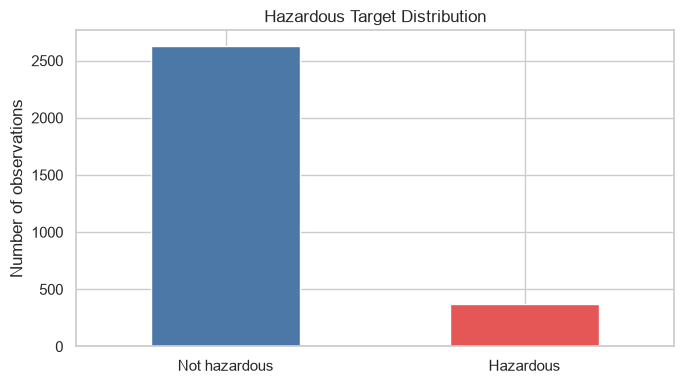

In [3]:
display(data.describe().T.round(3))

target_distribution = (
    data[TARGET]
    .value_counts()
    .rename(index={0: "Not hazardous", 1: "Hazardous"})
)
display(target_distribution.to_frame("observations"))

ax = target_distribution.plot(kind="bar", figsize=(7, 4), color=["#4C78A8", "#E45756"])
ax.set_title("Hazardous Target Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Correlation-based feature relevance

This section reproduces the purpose of RapidMiner's **Weight by Correlation** branch.

,correlation_with_hazardous
absolute_magnitude,-0.3409
est_diameter_max,0.2004
est_diameter_min,0.2004
relative_velocity,0.1847
miss_distance,-0.0398


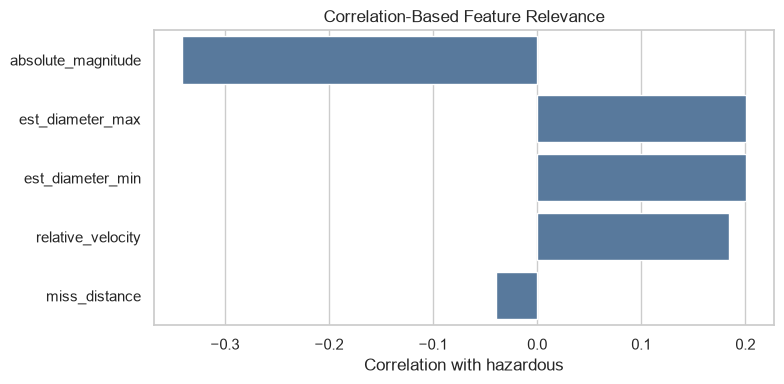

In [4]:
correlation_weights = (
    data.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .rename("correlation_with_hazardous")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
display(correlation_weights.to_frame().round(4))

plt.figure(figsize=(8, 4))
sns.barplot(x=correlation_weights.values, y=correlation_weights.index, color="#4C78A8")
plt.title("Correlation-Based Feature Relevance")
plt.xlabel("Correlation with hazardous")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 5. RapidMiner-equivalent preprocessing

Each numeric predictor is converted into five equal-frequency bins. The original workflow then creates a 20%/80% partition and sends the first partition to 10-fold cross-validation.

In [5]:
X = data[FEATURES].copy()
y = data[TARGET].copy()

X_cv, X_unused, y_cv, y_unused = train_test_split(
    X,
    y,
    train_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessing = ColumnTransformer(
    transformers=[
        (
            "frequency_bins",
            KBinsDiscretizer(
                n_bins=5,
                encode="ordinal",
                strategy="quantile",
                subsample=None,
            ),
            FEATURES,
        )
    ],
    verbose_feature_names_out=False,
)

decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=25,
    min_samples_leaf=2,
    min_samples_split=4,
    min_impurity_decrease=0.01,
    random_state=RANDOM_STATE,
)

model = Pipeline([
    ("discretisation", preprocessing),
    ("decision_tree", decision_tree),
])

print(f"Cross-validation partition: {len(X_cv):,} observations")
print(f"Unused second partition retained from the XML workflow: {len(X_unused):,} observations")

Cross-validation partition: 600 observations
Unused second partition retained from the XML workflow: 2,400 observations


## 6. Ten-fold cross-validation

In [6]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scores = cross_validate(
    model,
    X_cv,
    y_cv,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
    },
)

cv_results = pd.DataFrame({
    metric: scores[f"test_{metric}"]
    for metric in ["accuracy", "precision", "recall", "f1"]
})

display(cv_results.describe().loc[["mean", "std"]].T.round(4))

c:\Users\zedax\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\zedax\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,mean,std
accuracy,0.8733,0.0251
precision,0.3483,0.3528
recall,0.1643,0.1572
f1,0.2180,0.2058


## 7. Classification performance

Cross-validated accuracy: 0.8733

               precision    recall  f1-score   support

Not hazardous       0.89      0.97      0.93       526
    Hazardous       0.46      0.16      0.24        74

     accuracy                           0.87       600
    macro avg       0.68      0.57      0.59       600
 weighted avg       0.84      0.87      0.85       600



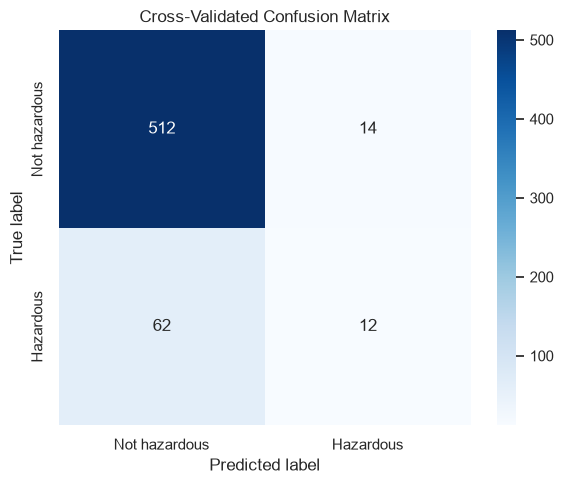

In [7]:
predictions = cross_val_predict(model, X_cv, y_cv, cv=cv)

print(f"Cross-validated accuracy: {accuracy_score(y_cv, predictions):.4f}\n")
print(classification_report(
    y_cv,
    predictions,
    target_names=["Not hazardous", "Hazardous"],
    zero_division=0,
))

matrix = confusion_matrix(y_cv, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not hazardous", "Hazardous"],
    yticklabels=["Not hazardous", "Hazardous"],
)
plt.title("Cross-Validated Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## 8. Final tree and feature importance

,importance
est_diameter_min,0.8986
miss_distance,0.1014
absolute_magnitude,0.0000
est_diameter_max,0.0000
relative_velocity,0.0000


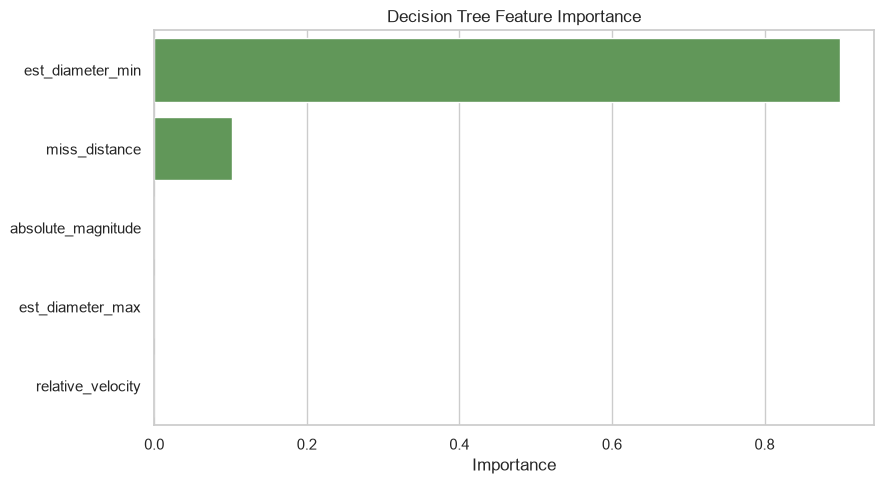

In [8]:
model.fit(X_cv, y_cv)

importance = pd.Series(
    model.named_steps["decision_tree"].feature_importances_,
    index=FEATURES,
    name="importance",
).sort_values(ascending=False)
display(importance.to_frame().round(4))

plt.figure(figsize=(9, 5))
sns.barplot(x=importance.values, y=importance.index, color="#59A14F")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Conclusions and limitations

- The notebook preserves the modelling sequence encoded in the RapidMiner XML.
- The hazardous class is less frequent, so precision, recall and F1 should be interpreted together with accuracy.
- Entropy is an approximation of RapidMiner's gain-ratio criterion, not an identical implementation.
- Cross-validation uses only the first 20% partition because that is how the original process is connected.
- Results are educational and should not be interpreted as an operational risk-assessment system.